In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import os
from astropy.table import Table
import seaborn as sns
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

In [2]:

hdulist = fits.open("../anac_data/CIGALE-test/out/observations.fits")
data = hdulist[1].data  # La tabla
print(data.columns)

ColDefs(
    name = 'id'; format = '8A'
    name = 'redshift'; format = 'D'
    name = 'F0378'; format = 'D'
    name = 'F0378_err'; format = 'D'
    name = 'F0395'; format = 'D'
    name = 'F0395_err'; format = 'D'
    name = 'F0410'; format = 'D'
    name = 'F0410_err'; format = 'D'
    name = 'F0430'; format = 'D'
    name = 'F0430_err'; format = 'D'
    name = 'F0515'; format = 'D'
    name = 'F0515_err'; format = 'D'
    name = 'F0660'; format = 'D'
    name = 'F0660_err'; format = 'D'
    name = 'F0861'; format = 'D'
    name = 'F0861_err'; format = 'D'
)


In [3]:
def convert_metallicity_to_FeH(Z, Z_solar=0.0152):
    """Convertir metalicidad Z a [Fe/H]"""
    return np.log10(Z / Z_solar)

def plot_splus_gc_sed_with_residuals(obj_id, 
                                    observations_file='../anac_data/CIGALE-test/out/observations.fits', 
                                    results_file='../anac_data/CIGALE-test/out/results.fits',
                                    output_dir='../anac_data/CIGALE-test/',
                                    Z_solar=0.0152):
    """
    Gráfico SED especializado para cúmulos globulares con filtros S-PLUS
    
    Parameters:
    -----------
    obj_id : str or int
        ID del objeto (cúmulo globular)
    observations_file : str
        Ruta al archivo observations.fits de CIGALE
    results_file : str
        Ruta al archivo results.fits de CIGALE  
    output_dir : str
        Directorio donde guardar el gráfico
    Z_solar : float
        Metalicidad solar (por defecto 0.0152 de Asplund+ 2009)
    """
    
    def get_actual_model_metallicity(obj_id, results_file):
        """Obtener la metalicidad REAL del modelo específico"""
        try:
            results = Table.read(results_file)
            res_obj = results[results['id'] == obj_id]
            
            # Buscar la metalicidad real del modelo (no el prior)
            # En CIGALE, la metalicidad del modelo real puede estar en diferentes columnas
            metallicity_keys = [
                'best.stellar.metallicity',
                'bayes.stellar.metallicity', 
                'stellar.metallicity'
            ]
            
            for key in metallicity_keys:
                if key in res_obj.colnames:
                    actual_Z = res_obj[key][0]
                    print(f"🔍 Metalicidad encontrada en '{key}': {actual_Z:.6f}")
                    return actual_Z
            
            # Si no encontramos ninguna columna específica, usar la por defecto
            default_Z = res_obj['best.stellar.metallicity'][0]
            print(f"⚠️  Usando metalicidad por defecto: {default_Z:.6f}")
            return default_Z
            
        except Exception as e:
            print(f"❌ Error obteniendo metalicidad real: {e}")
            return None
    
    try:
        # Leer archivos de CIGALE
        model = Table.read(f'../anac_data/CIGALE-test/out/{obj_id}_best_model.fits')
        obs = Table.read(observations_file)
        results = Table.read(results_file)
        
        # Filtrar datos para el objeto específico
        obs_obj = obs[obs['id'] == obj_id]
        res_obj = results[results['id'] == obj_id]
        
        # Obtener parámetros físicos clave
        reduced_chi2 = res_obj['best.reduced_chi_square'][0]
        stellar_mass = res_obj['best.stellar.m_star'][0]
        
        # OBTENER METALICIDAD REAL DEL MODELO
        metallicity_Z = get_actual_model_metallicity(obj_id, results_file)
        if metallicity_Z is None:
            print("❌ No se pudo obtener la metalicidad real, usando valor por defecto")
            metallicity_Z = res_obj['bayes.stellar.metallicity'][0]
        
        age = res_obj['best.stellar.age_m_star'][0]
        
        # Convertir a [Fe/H]
        FeH = convert_metallicity_to_FeH(metallicity_Z, Z_solar)
        
        print(f"📊 Analizando objeto {obj_id}:")
        print(f"   Masa estelar: {stellar_mass:.2e} M_sun")
        print(f"   Metalicidad Z REAL: {metallicity_Z:.6f}")
        print(f"   [Fe/H]: {FeH:.3f}")
        print(f"   Edad: {age:.0f} Myr")
        print(f"   χ² reducido: {reduced_chi2:.2f}")
        
        # DEBUG: Mostrar comparación de valores
        print(f"🔍 Comparación:")
        print(f"   - Metalicidad real del modelo: {metallicity_Z:.6f}")
        print(f"   - Prior/valor inicial: 0.004000")
        
    except FileNotFoundError as e:
        print(f"❌ Error: No se encontró el objeto {obj_id}")
        print(f"   Asegúrate de que existe: ../anac_data/CIGALE-test/out/{obj_id}_best_model.fits")
        return
    except Exception as e:
        print(f"❌ Error leyendo archivos: {e}")
        return

    # Configurar el gráfico con estilo para publicación
    plt.style.use('default')  # Reset para tener control total
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                                  gridspec_kw={'height_ratios': [2, 1]})
    
    # Convertir nm a μm para mejor visualización
    wavelength_um = model['wavelength'] / 1000.0
    
    # --- Panel 1: SED completo ---
    # Modelo total - línea más fina y elegante
    ax1.loglog(wavelength_um, model['Fnu'], 'k-', linewidth=1.0, 
              label='Total Model', alpha=0.6)
    
    # Componentes (ajustados para cúmulos globulares)
    if 'stellar' in model.colnames:
        ax1.loglog(wavelength_um, model['stellar'], 'steelblue', alpha=0.6, 
                  linewidth=1.0, label='Stellar Component', linestyle='--')
    
    # Filtros S-PLUS con sus longitudes de onda efectivas
    splus_filters = {
        'F0378': (0.378, '#4A148C', 'J0378'),  # Púrpura oscuro
        'F0395': (0.395, '#6A1B9A', 'J0395'),  # Púrpura  
        'F0410': (0.410, '#283593', 'J0410'),  # Azul índigo
        'F0430': (0.430, '#0277BD', 'J0430'),  # Azul
        'F0515': (0.515, '#00897B', 'J0515'),  # Verde azulado
        'F0660': (0.660, '#E65100', 'J0660'),  # Naranja oscuro
        'F0861': (0.861, '#BF360C', 'J0861')   # Rojo oscuro
    }
    
    residuals_data = []
    
    for filter_name, (wave, color, band_short) in splus_filters.items():
        if filter_name in obs_obj.colnames:
            # Flujo observado
            flux_obs = obs_obj[filter_name][0]
            flux_err = obs_obj[filter_name + '_err'][0]
            
            # Flujo del modelo (en results)
            model_flux_col = f'best.{filter_name}'
            if model_flux_col in res_obj.colnames:
                flux_model = res_obj[model_flux_col][0]
                
                # Calcular residuo normalizado
                residual = (flux_obs - flux_model) / flux_err
                
                # Plot observación - CUADRADOS VACÍOS MÁS GRANDES
                ax1.errorbar(wave, flux_obs, yerr=flux_err, 
                            fmt='s', markerfacecolor='none', markeredgecolor=color, 
                            markersize=10, capsize=3, markeredgewidth=1.5,
                            ecolor=color,  # Barras de error del mismo color
                            label=f'Obs {band_short}', alpha=0.9, zorder=5)
                
                # Plot flujo del modelo - CÍRCULOS SÓLIDOS DE COLOR ATRACTIVO
                ax1.plot(wave, flux_model, marker='o', markersize=6, 
                        markerfacecolor='#E91E63', markeredgecolor='#E91E63', 
                        linestyle='', label=f'Model fluxes', alpha=0.9, zorder=4)
                
                # Guardar datos para residuos
                residuals_data.append({
                    'band': band_short,
                    'filter_name': filter_name,
                    'wave': wave,
                    'obs': flux_obs,
                    'model': flux_model, 
                    'error': flux_err,
                    'residual': residual,
                    'color': color
                })
    
    # Configurar panel 1 - Estilo para publicación
    ax1.set_xlabel('Wavelength (μm)', fontsize=18, fontweight='normal')
    ax1.set_ylabel('Flux (mJy)', fontsize=18, fontweight='normal')
    
    # Título con [Fe/H] REAL del modelo
    title_text = (f'GC {obj_id} | '
                 f'M = {stellar_mass:.2e} M$_\odot$ | '
                 f'[Fe/H] = {FeH:.2f} | '
                 f'Age = {age/1000:.1f} Gyr | '
                 f'$\chi^2$ = {reduced_chi2:.2f}')
    ax1.set_title(title_text, fontsize=16, pad=10)
    
    # Leyenda mejorada y compacta
    handles, labels = ax1.get_legend_handles_labels()
    # Mantener solo una entrada por tipo (no duplicados por filtro)
    unique_labels = []
    unique_handles = []
    for handle, label in zip(handles, labels):
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handle)
    
    # Ordenar leyenda: primero componentes del modelo, luego observaciones
    model_handles = [h for h, l in zip(unique_handles, unique_labels) if 'Model' in l or 'Component' in l]
    model_labels = [l for l in unique_labels if 'Model' in l or 'Component' in l]
    obs_handles = [h for h, l in zip(unique_handles, unique_labels) if 'Obs' in l]
    obs_labels = [l for l in unique_labels if 'Obs' in l]
    
    # Reconstruir leyenda ordenada
    ordered_handles = model_handles + obs_handles
    ordered_labels = model_labels + obs_labels
    
    ax1.legend(ordered_handles, ordered_labels, loc='best', 
              ncol=2, fontsize=14, framealpha=0.9, fancybox=True)
    
    ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    ax1.set_xlim(0.3, 1.0)
    ax1.xaxis.set_visible(False) 
    ax1.set_yticklabels(ax1.get_yticks(), fontsize=16) 

    # Ajuste automático del rango Y
    if residuals_data:
        all_fluxes = [d['obs'] for d in residuals_data] + [d['model'] for d in residuals_data]
        min_flux = min(all_fluxes) * 0.3
        max_flux = max(all_fluxes) * 3.0
        ax1.set_ylim(min_flux, max_flux)
    
    # --- Panel 2: Residuos ---
    if residuals_data:
        bands = [d['band'] for d in residuals_data]
        waves = [d['wave'] for d in residuals_data]
        residuals = [d['residual'] for d in residuals_data]
        colors = [d['color'] for d in residuals_data]
        
        # Plot residuos - mantener colores originales de filtros
        for i, (band, wave, residual, color) in enumerate(zip(bands, waves, residuals, colors)):
            ax2.scatter(wave, residual, color=color, s=80, zorder=3, 
                       marker='s', label=f'{band}', alpha=0.8, edgecolors='black', linewidth=0.5)
            
            # Conectar puntos con líneas para mejor visualización
            if i > 0:
                prev_wave = waves[i-1]
                prev_residual = residuals[i-1]
                ax2.plot([prev_wave, wave], [prev_residual, residual], 
                        'gray', alpha=0.3, linestyle='-', linewidth=1)
        
        # Líneas de referencia más sutiles
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
        ax2.axhline(y=1, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
        ax2.axhline(y=-1, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
        ax2.axhline(y=2, color='red', linestyle=':', alpha=0.3, linewidth=0.6)
        ax2.axhline(y=-2, color='red', linestyle=':', alpha=0.3, linewidth=0.6)
        
        ax2.set_xlabel('Wavelength (μm)', fontsize=18, fontweight='normal')
        ax2.set_ylabel('Residual (σ)', fontsize=18, fontweight='normal')
        ax2.tick_params(axis='both', which='major', labelsize=26)
        ax2.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
        ax2.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
        ax2.set_xscale('log')
        ax2.set_xlim(0.3, 1.0) 
        
        # Ajustar límites Y para residuos
        max_res = max(3, max(np.abs(residuals)) * 1.2)
        ax2.set_ylim(-max_res, max_res)
        ax2.tick_params(axis='both', which='major', labelsize=26)
    
    # Ajustes finales de estilo
    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', which='major', labelsize=18)
        ax.tick_params(axis='both', which='minor', labelsize=18)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.01)  # Menos espacio entre subplots
    
    # Guardar gráfico con alta calidad para publicación
    output_path = f'{output_dir}/{obj_id}_SED_S-PLUS.png'
    output_path1 = f'{output_dir}/{obj_id}_SED_S-PLUS.pdf'
    plt.savefig(output_path, dpi=350, bbox_inches='tight', facecolor='white', 
                transparent=False, pad_inches=0.1)
    plt.savefig(output_path1, dpi=350, bbox_inches='tight', facecolor='white', 
                transparent=False, pad_inches=0.1)
    print(f"✅ Gráfico guardado: {output_path}")
    plt.show()
    
    # Imprimir tabla de residuos detallada
    if residuals_data:
        print(f"\n{'='*60}")
        print(f"ANÁLISIS DE RESIDUOS - Cúmulo Globular {obj_id}")
        print(f"{'='*60}")
        print(f"{'Filtro':<8} {'λ (μm)':<8} {'Obs (mJy)':<12} {'Model (mJy)':<12} {'Residuo (σ)':<12} {'|Residuo|':<10}")
        print(f"{'-'*60}")
        
        for data in residuals_data:
            abs_residual = abs(data['residual'])
            print(f"{data['band']:<8} {data['wave']:<8.3f} {data['obs']:<12.6f} "
                  f"{data['model']:<12.6f} {data['residual']:<12.2f} {abs_residual:<10.2f}")
        
        print(f"{'-'*60}")
        avg_abs_residual = np.mean([abs(d['residual']) for d in residuals_data])
        print(f"Residuo absoluto promedio: {avg_abs_residual:.2f}σ")
        print(f"Número de puntos: {len(residuals_data)}")
        print(f"{'='*60}")

# Función auxiliar para plotear múltiples objetos
def plot_multiple_gcs(obj_ids, **kwargs):
    """
    Plotear SEDs para múltiples cúmulos globulares
    
    Parameters:
    -----------
    obj_ids : list
        Lista de IDs de objetos a plotear
    **kwargs : 
        Argumentos adicionales para plot_splus_gc_sed_with_residuals
    """
    for obj_id in obj_ids:
        print(f"\n{'#'*50}")
        print(f"PROCESANDO OBJETO: {obj_id}")
        print(f"{'#'*50}")
        plot_splus_gc_sed_with_residuals(obj_id, **kwargs)

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.004000
📊 Analizando objeto T17-2602:
   Masa estelar: 2.59e+06 M_sun
   Metalicidad Z REAL: 0.004000
   [Fe/H]: -0.580
   Edad: 10989 Myr
   χ² reducido: 0.27
🔍 Comparación:
   - Metalicidad real del modelo: 0.004000
   - Prior/valor inicial: 0.004000
✅ Gráfico guardado: ../anac_data/CIGALE-test//T17-2602_SED_S-PLUS.png


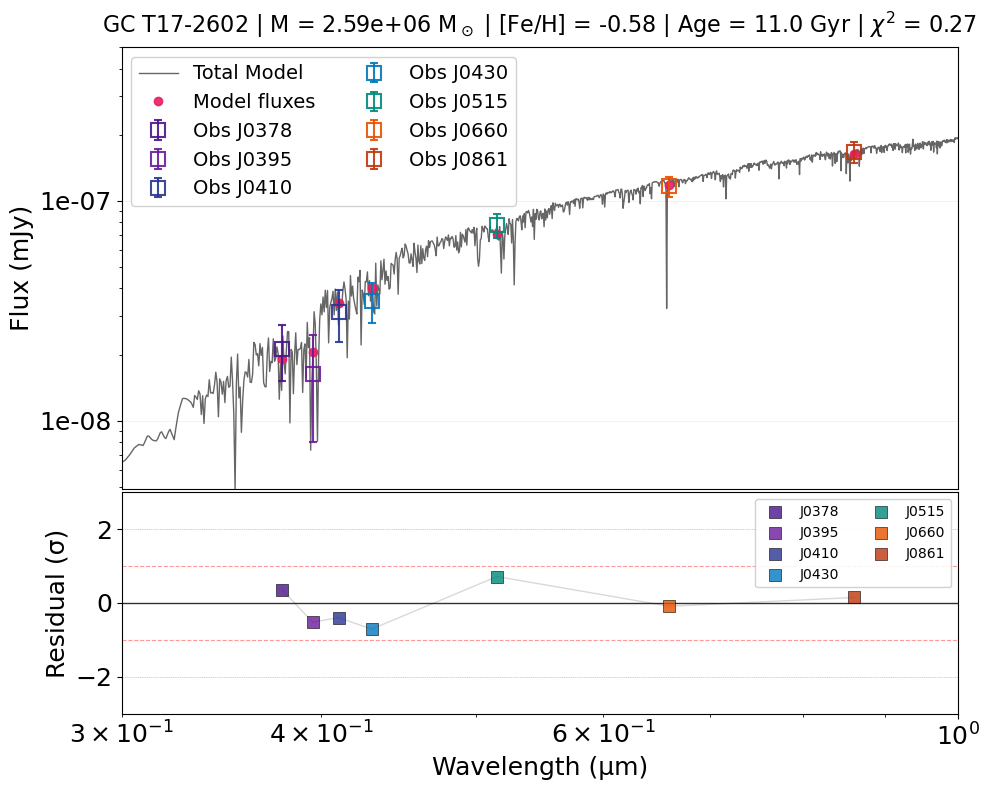


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2602
Filtro   λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
------------------------------------------------------------
J0378    0.378    0.021280     0.019106     0.36         0.36      
J0395    0.395    0.016312     0.020647     -0.52        0.52      
J0410    0.410    0.031217     0.034494     -0.40        0.40      
J0430    0.430    0.035083     0.040170     -0.71        0.71      
J0515    0.515    0.077707     0.070865     0.72         0.72      
J0660    0.660    0.116560     0.117644     -0.09        0.09      
J0861    0.861    0.167033     0.164255     0.15         0.15      
------------------------------------------------------------
Residuo absoluto promedio: 0.42σ
Número de puntos: 7


In [4]:
# Ejemplo de uso:
if __name__ == "__main__":
    # Plotear un objeto individual
    plot_splus_gc_sed_with_residuals('T17-2602')


## Other example

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.004000
📊 Analizando objeto T17-2211:
   Masa estelar: 6.23e+05 M_sun
   Metalicidad Z REAL: 0.004000
   [Fe/H]: -0.580
   Edad: 4569 Myr
   χ² reducido: 0.05
🔍 Comparación:
   - Metalicidad real del modelo: 0.004000
   - Prior/valor inicial: 0.004000
✅ Gráfico guardado: ../anac_data/CIGALE-test//T17-2211_SED_S-PLUS.png


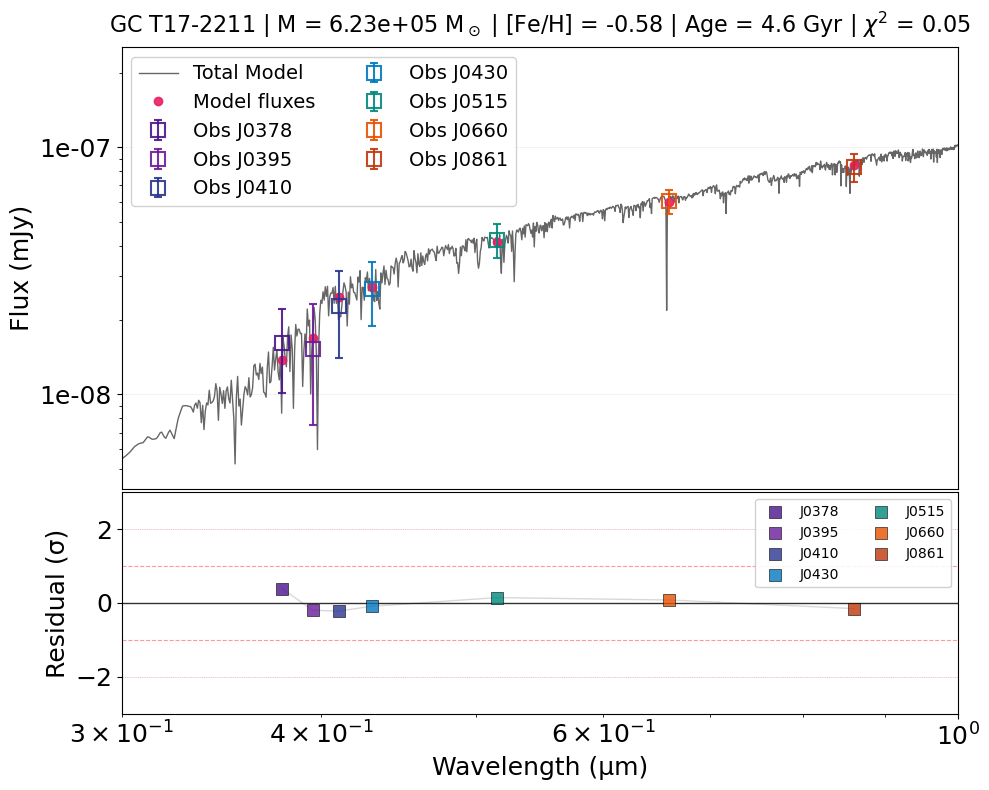


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2211
Filtro   λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
------------------------------------------------------------
J0378    0.378    0.016154     0.013768     0.39         0.39      
J0395    0.395    0.015309     0.016842     -0.20        0.20      
J0410    0.410    0.022751     0.024669     -0.22        0.22      
J0430    0.430    0.026577     0.027265     -0.09        0.09      
J0515    0.515    0.042196     0.041214     0.15         0.15      
J0660    0.660    0.060499     0.059958     0.08         0.08      
J0861    0.861    0.083140     0.084838     -0.15        0.15      
------------------------------------------------------------
Residuo absoluto promedio: 0.18σ
Número de puntos: 7


In [5]:
plot_splus_gc_sed_with_residuals('T17-2211')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-2684:
   Masa estelar: 2.26e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 8987 Myr
   χ² reducido: 0.48
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
   - Prior/valor inicial: 0.004000
✅ Gráfico guardado: ../anac_data/CIGALE-test//T17-2684_SED_S-PLUS.png


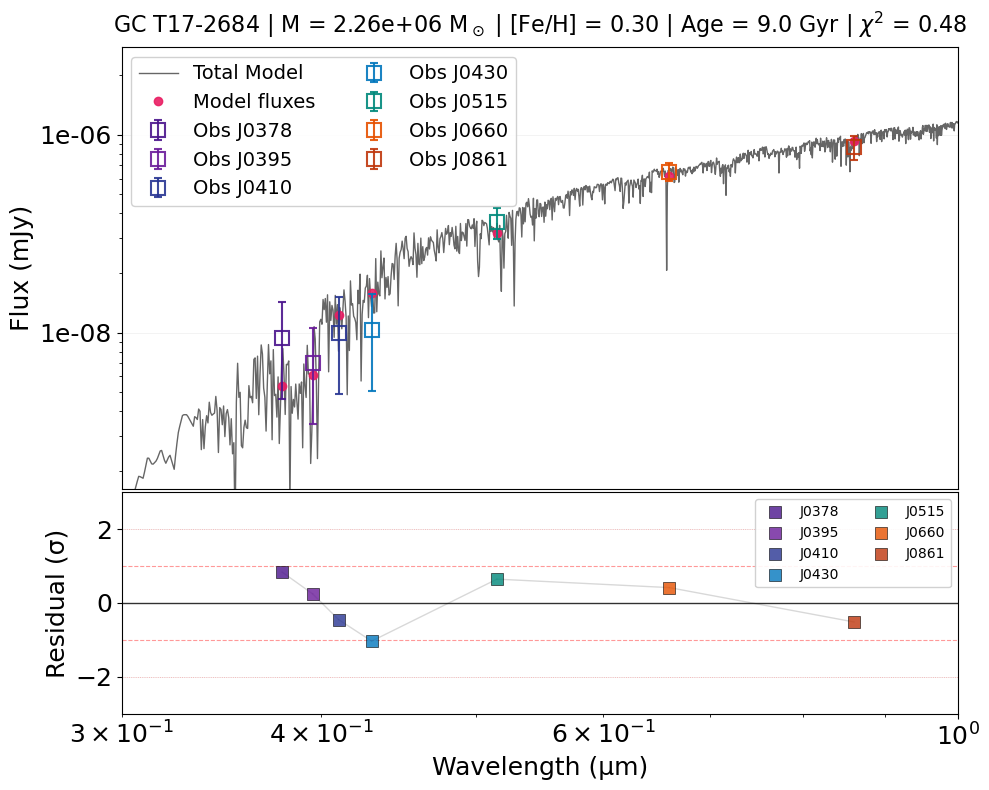


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2684
Filtro   λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
------------------------------------------------------------
J0378    0.378    0.009411     0.005385     0.84         0.84      
J0395    0.395    0.007014     0.006131     0.25         0.25      
J0410    0.410    0.009968     0.012255     -0.45        0.45      
J0430    0.430    0.010337     0.015795     -1.04        1.04      
J0515    0.515    0.036126     0.031940     0.65         0.65      
J0660    0.660    0.065133     0.062169     0.42         0.42      
J0861    0.861    0.086497     0.092585     -0.52        0.52      
------------------------------------------------------------
Residuo absoluto promedio: 0.59σ
Número de puntos: 7


In [6]:
plot_splus_gc_sed_with_residuals('T17-2684')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-2698:
   Masa estelar: 1.43e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 7187 Myr
   χ² reducido: 0.56
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
   - Prior/valor inicial: 0.004000
✅ Gráfico guardado: ../anac_data/CIGALE-test//T17-2698_SED_S-PLUS.png


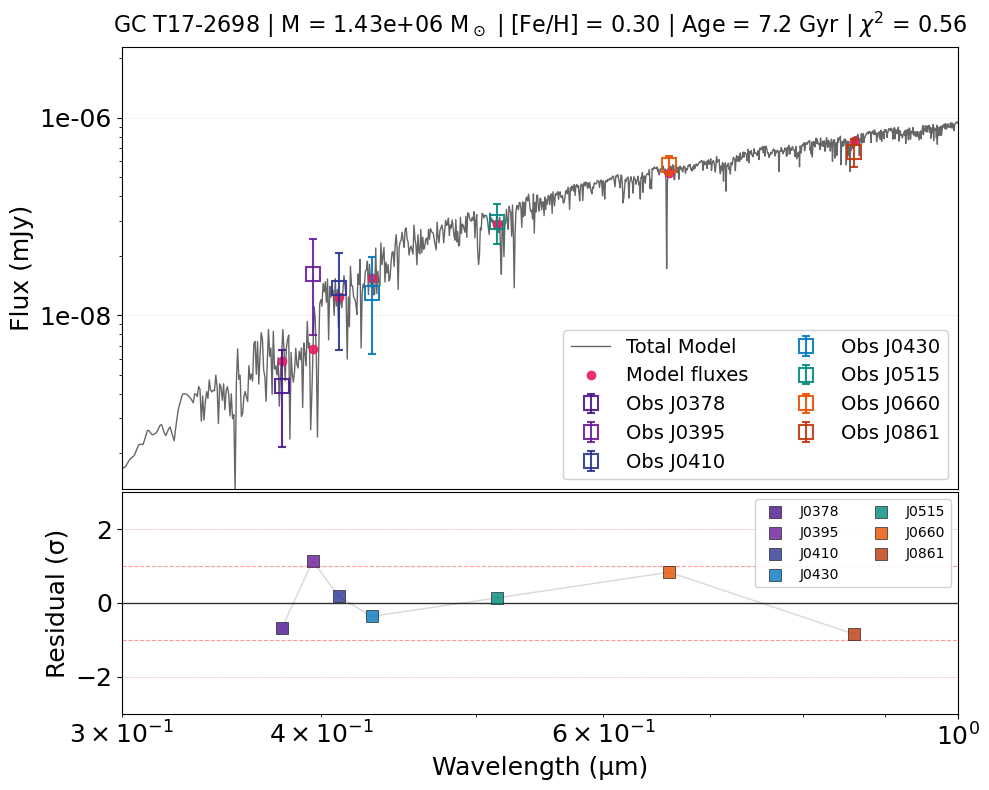


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2698
Filtro   λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
------------------------------------------------------------
J0378    0.378    0.004389     0.005880     -0.67        0.67      
J0395    0.395    0.016111     0.006762     1.14         1.14      
J0410    0.410    0.013662     0.012373     0.18         0.18      
J0430    0.430    0.013015     0.015434     -0.36        0.36      
J0515    0.515    0.029780     0.028847     0.14         0.14      
J0660    0.660    0.057732     0.052315     0.83         0.83      
J0861    0.861    0.066898     0.075953     -0.84        0.84      
------------------------------------------------------------
Residuo absoluto promedio: 0.60σ
Número de puntos: 7


In [7]:
plot_splus_gc_sed_with_residuals('T17-2698')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.000400
📊 Analizando objeto T17-2731:
   Masa estelar: 9.49e+05 M_sun
   Metalicidad Z REAL: 0.000400
   [Fe/H]: -1.580
   Edad: 6277 Myr
   χ² reducido: 0.61
🔍 Comparación:
   - Metalicidad real del modelo: 0.000400
   - Prior/valor inicial: 0.004000
✅ Gráfico guardado: ../anac_data/CIGALE-test//T17-2731_SED_S-PLUS.png


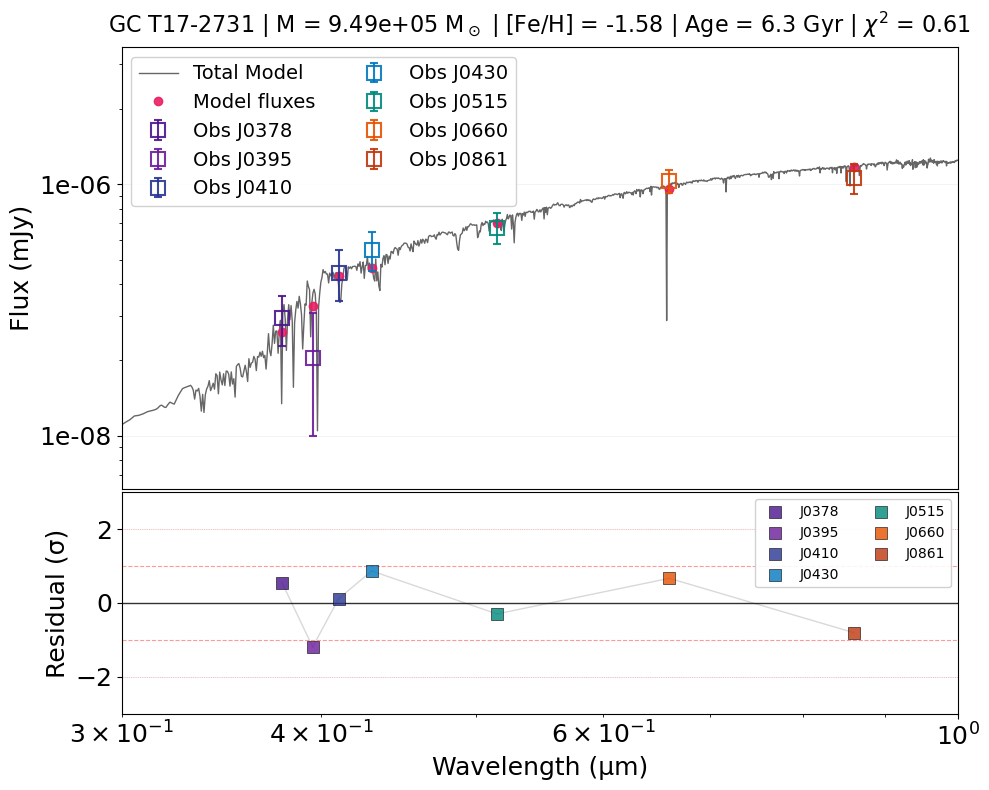


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2731
Filtro   λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
------------------------------------------------------------
J0378    0.378    0.029382     0.025759     0.55         0.55      
J0395    0.395    0.020425     0.032829     -1.19        1.19      
J0410    0.410    0.044501     0.043355     0.11         0.11      
J0430    0.430    0.054893     0.046526     0.87         0.87      
J0515    0.515    0.067154     0.069955     -0.30        0.30      
J0660    0.660    0.103329     0.095934     0.67         0.67      
J0861    0.861    0.105874     0.117323     -0.81        0.81      
------------------------------------------------------------
Residuo absoluto promedio: 0.64σ
Número de puntos: 7


In [11]:
plot_splus_gc_sed_with_residuals('T17-2731')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.004000
📊 Analizando objeto T17-2741:
   Masa estelar: 1.61e+06 M_sun
   Metalicidad Z REAL: 0.004000
   [Fe/H]: -0.580
   Edad: 9988 Myr
   χ² reducido: 0.91
🔍 Comparación:
   - Metalicidad real del modelo: 0.004000
   - Prior/valor inicial: 0.004000
✅ Gráfico guardado: ../anac_data/CIGALE-test//T17-2741_SED_S-PLUS.png


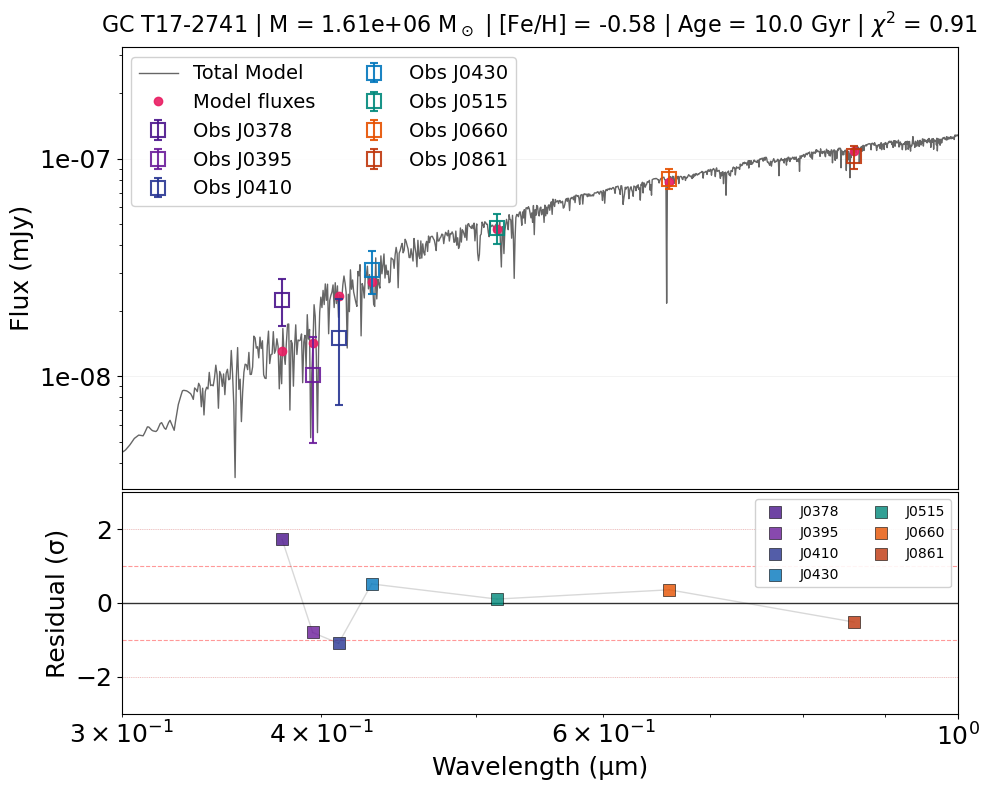


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2741
Filtro   λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
------------------------------------------------------------
J0378    0.378    0.022526     0.013083     1.72         1.72      
J0395    0.395    0.010090     0.014208     -0.80        0.80      
J0410    0.410    0.015040     0.023442     -1.10        1.10      
J0430    0.430    0.030773     0.027209     0.52         0.52      
J0515    0.515    0.048311     0.047506     0.11         0.11      
J0660    0.660    0.081197     0.078129     0.36         0.36      
J0861    0.861    0.102620     0.109087     -0.52        0.52      
------------------------------------------------------------
Residuo absoluto promedio: 0.73σ
Número de puntos: 7


In [12]:
plot_splus_gc_sed_with_residuals('T17-2741')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.004000
📊 Analizando objeto T17-3019:
   Masa estelar: 3.37e+06 M_sun
   Metalicidad Z REAL: 0.004000
   [Fe/H]: -0.580
   Edad: 7986 Myr
   χ² reducido: 0.06
🔍 Comparación:
   - Metalicidad real del modelo: 0.004000
   - Prior/valor inicial: 0.004000
✅ Gráfico guardado: ../anac_data/CIGALE-test//T17-3019_SED_S-PLUS.png


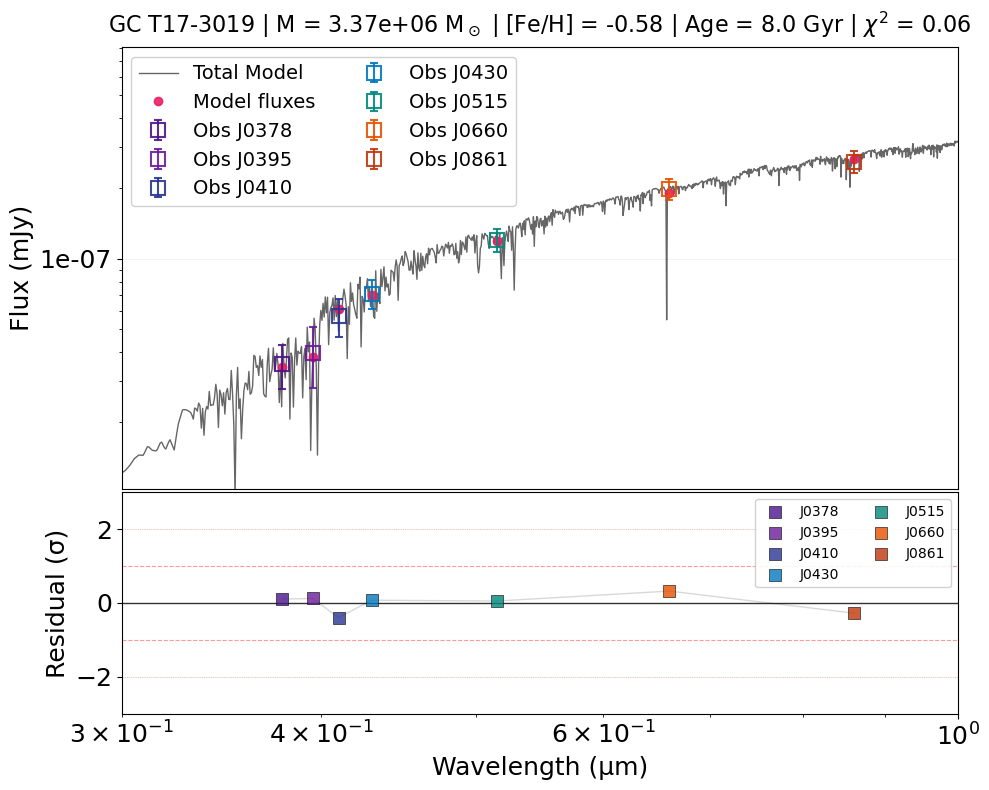


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-3019
Filtro   λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
------------------------------------------------------------
J0378    0.378    0.035356     0.034555     0.11         0.11      
J0395    0.395    0.039525     0.038117     0.12         0.12      
J0410    0.410    0.056842     0.061047     -0.40        0.40      
J0430    0.430    0.071012     0.070265     0.08         0.08      
J0515    0.515    0.120185     0.119468     0.05         0.05      
J0660    0.660    0.198543     0.191992     0.32         0.32      
J0861    0.861    0.260528     0.268151     -0.28        0.28      
------------------------------------------------------------
Residuo absoluto promedio: 0.19σ
Número de puntos: 7


In [13]:
plot_splus_gc_sed_with_residuals('T17-3019')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-2911:
   Masa estelar: 3.18e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 9070 Myr
   χ² reducido: 1.02
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
   - Prior/valor inicial: 0.004000
✅ Gráfico guardado: ../anac_data/CIGALE-test//T17-2911_SED_S-PLUS.png


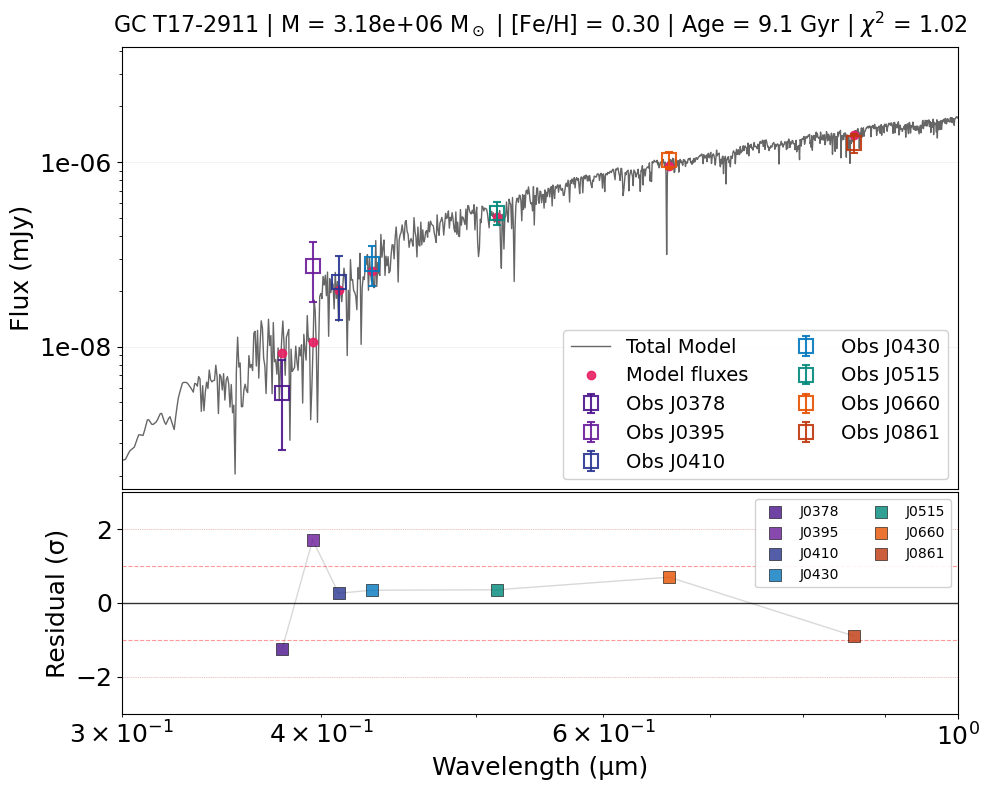


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2911
Filtro   λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
------------------------------------------------------------
J0378    0.378    0.005642     0.009239     -1.25        1.25      
J0395    0.395    0.027248     0.010625     1.71         1.71      
J0410    0.410    0.022536     0.020284     0.26         0.26      
J0430    0.430    0.028144     0.025761     0.35         0.35      
J0515    0.515    0.052914     0.050228     0.36         0.36      
J0660    0.660    0.102443     0.094995     0.70         0.70      
J0861    0.861    0.126642     0.140023     -0.90        0.90      
------------------------------------------------------------
Residuo absoluto promedio: 0.79σ
Número de puntos: 7


In [14]:
plot_splus_gc_sed_with_residuals('T17-2911')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.004000
📊 Analizando objeto T17-2818:
   Masa estelar: 1.40e+06 M_sun
   Metalicidad Z REAL: 0.004000
   [Fe/H]: -0.580
   Edad: 10989 Myr
   χ² reducido: 1.02
🔍 Comparación:
   - Metalicidad real del modelo: 0.004000
   - Prior/valor inicial: 0.004000
✅ Gráfico guardado: ../anac_data/CIGALE-test//T17-2818_SED_S-PLUS.png


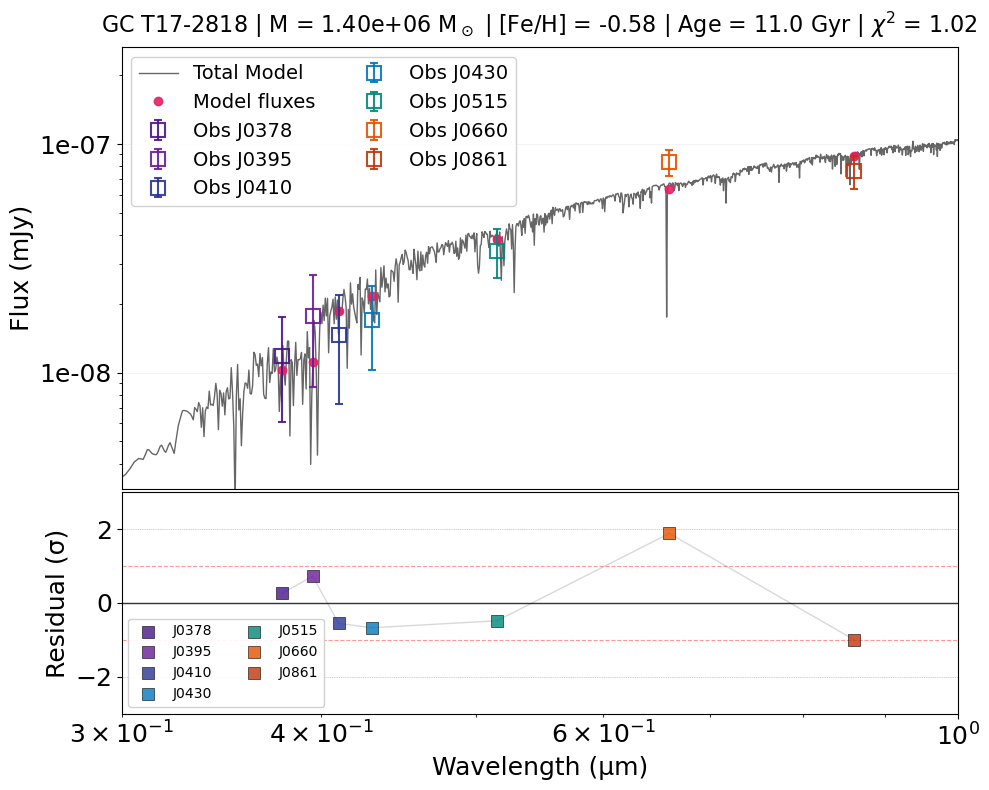


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2818
Filtro   λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
------------------------------------------------------------
J0378    0.378    0.011802     0.010306     0.26         0.26      
J0395    0.395    0.017710     0.011138     0.73         0.73      
J0410    0.410    0.014597     0.018608     -0.55        0.55      
J0430    0.430    0.017073     0.021669     -0.67        0.67      
J0515    0.515    0.034209     0.038227     -0.48        0.48      
J0660    0.660    0.083387     0.063461     1.89         1.89      
J0861    0.861    0.075953     0.088605     -1.00        1.00      
------------------------------------------------------------
Residuo absoluto promedio: 0.80σ
Número de puntos: 7


In [15]:
plot_splus_gc_sed_with_residuals('T17-2818')